# Full-Range Data Augmentation (0.1 – 100 µM)

This notebook extends the augmentation logic from `data_augmentation.ipynb` to cover the **complete experimental concentration interval**: `[0.1, 0.25, 0.5, 1, 2.5, 5, 7.5, 10, 15, 25, 50, 100] µM`.

### Key additions over the `[7.5, 20] µM` notebook

| Challenge | Solution |
|---|---|
| **Non-linearity at high concentrations (≥ 25 µM)** | Monotone cubic (PCHIP) spline fitted to empirical Ip values; per-segment dynamic α scaling |
| **Stratified oversampling of the low-concentration tail (< 2.5 µM)** | Concentration-proportional sample allocation with noise amplification |
| **Extended `get_base_pair` logic** | Covers all 12 anchor concentrations with automatic segment lookup |
| **Full `Signal` + `vectorize` compatibility** | Baseline-subtraction bypass identical to the parent notebook |

### Workflow
1. Load data & build all 12 mean base curves  
2. Characterise the Ip–concentration relationship (linearity check, PCHIP fit)  
3. Physics-informed augmentation: PCHIP interpolation + Gaussian noise + baseline variation + potential drift  
4. Stratified sampling — oversampling of the low-concentration tail  
5. Route synthetic signals through the `Signal` + `vectorize` pipeline  
6. Persist combined CSVs for model training

In [22]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter
from scipy.stats import linregress

from sklearn.preprocessing import StandardScaler

# project-specific classes
from voltammogram_signal import Signal
from peak import Peak

warnings.filterwarnings('ignore')
np.random.seed(42)

### Load Data

Identical loading block to the parent notebook. All 12 experimental concentration levels are used as anchors.

In [ ]:
DATASET_PATH = 'datasets/Standard calibration in culture media_extended.xlsx'

df_raw = pd.read_excel(DATASET_PATH, sheet_name='Raw data')

E_global        = df_raw.iloc[1:, 0].values.astype(float)  # potential (V)
I_baseline_raw  = df_raw.iloc[1:, 1].values.astype(float)  # blank / baseline (µA)
signals_raw     = df_raw.iloc[1:, 2:].values.astype(float) # signal matrix (µA)

# Full concentration label list matching the 40 signal columns
CONCENTRATIONS = [
    100, 100, 100,
    50,  50,  50,
    25,  25,  25,
    15,  15,  15,
    10,  10,  10,
    7.5, 7.5, 7.5,
    5,   5,   5,
    2.5, 2.5,
    1,   1,   1,
    0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
    0.25, 0.25, 0.25,
    0.1,  0.1,  0.1,  0.1,  0.1,
]

# All 12 unique anchor concentrations — ordered low to high
ANCHOR_CONCENTRATIONS = [0.1, 0.25, 0.5, 1.0, 2.5, 5.0, 7.5, 10.0, 15.0, 25.0, 50.0, 100.0]

print(f"Potential range  : {E_global.min():.4f} V  →  {E_global.max():.4f} V")
print(f"Number of points : {len(E_global)}")
print(f"Signal columns   : {signals_raw.shape[1]}")
print(f"Anchor concentrations: {ANCHOR_CONCENTRATIONS}")

Potential range  : -0.6001 V  →  0.5023 V
Number of points : 229
Signal columns   : 40
Anchor concentrations: [0.1, 0.25, 0.5, 1.0, 2.5, 5.0, 7.5, 10.0, 15.0, 25.0, 50.0, 100.0]


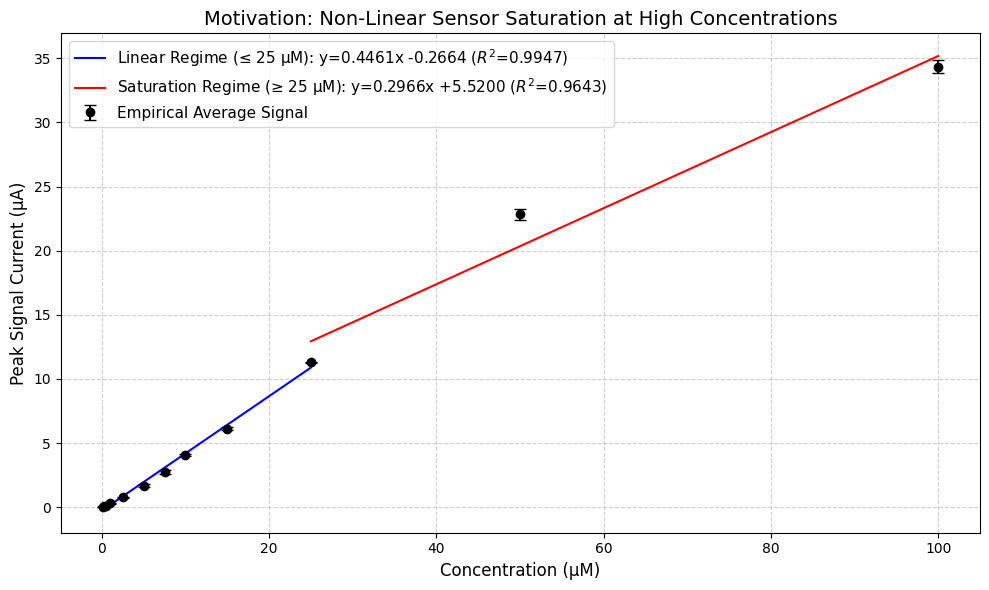

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# FIX: Use the string filename in quotes, not the df_raw variable
excel_path = 'datasets/Standard calibration in culture media_extended.xlsx'

# Load the calibration summary sheet
df_cc = pd.read_excel(excel_path, sheet_name='CC')

# 2. Extract the relevant rows and columns 
# (Columns 10, 17, and 18 correspond to Concentration, Average Signal, and Stdev)
data = df_cc.iloc[4:16, [10, 17, 18]].copy()
data.columns = ['Concentration', 'Signal', 'Stdev']
data = data.dropna()

# Ensure numeric types and sort
data['Concentration'] = pd.to_numeric(data['Concentration'])
data['Signal'] = pd.to_numeric(data['Signal'])
data['Stdev'] = pd.to_numeric(data['Stdev'])
data = data.sort_values('Concentration')

# 3. Split data at the 25 uM saturation breakpoint
low_data = data[data['Concentration'] <= 25.0]
high_data = data[data['Concentration'] >= 25.0]

# 4. Calculate dual linear fits
slope_low, int_low, r_low, _, _ = linregress(low_data['Concentration'], low_data['Signal'])
slope_high, int_high, r_high, _, _ = linregress(high_data['Concentration'], high_data['Signal'])

# 5. Generate the plot
plt.figure(figsize=(10, 6))

# Plot experimental points
plt.errorbar(data['Concentration'], data['Signal'], yerr=data['Stdev'], 
             fmt='ko', label='Empirical Average Signal', capsize=4)

# Plot low range line
plt.plot(low_data['Concentration'], int_low + slope_low * low_data['Concentration'], 'b-', 
         label=f'Linear Regime (≤ 25 µM): y={slope_low:.4f}x {int_low:+.4f} ($R^2$={r_low**2:.4f})')

# Plot high range line
plt.plot(high_data['Concentration'], int_high + slope_high * high_data['Concentration'], 'r-', 
         label=f'Saturation Regime (≥ 25 µM): y={slope_high:.4f}x {int_high:+.4f} ($R^2$={r_high**2:.4f})')

plt.title('Motivation: Non-Linear Sensor Saturation at High Concentrations', fontsize=14)
plt.xlabel('Concentration (µM)', fontsize=12)
plt.ylabel('Peak Signal Current (µA)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

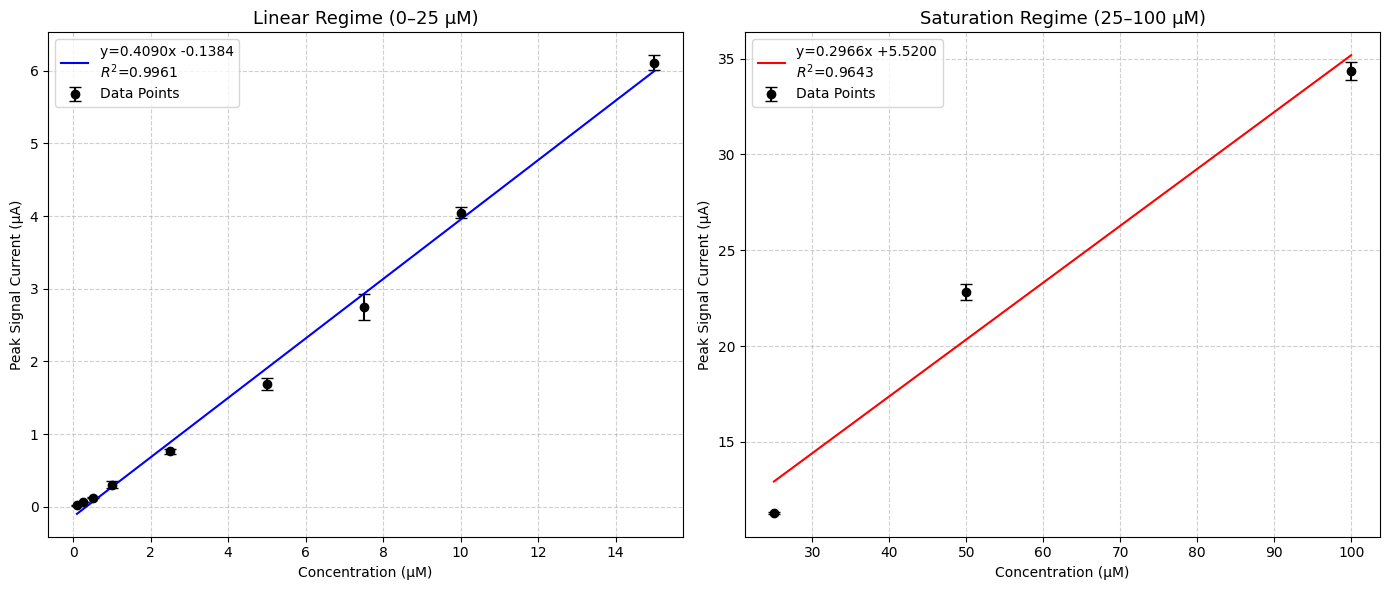

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Load the data
excel_path = 'datasets/Standard calibration in culture media_extended.xlsx'
df_cc = pd.read_excel(excel_path, sheet_name='CC')

# 1. Prepare data
data = df_cc.iloc[4:16, [10, 17, 18]].copy()
data.columns = ['Concentration', 'Signal', 'Stdev']
data = data.apply(pd.to_numeric, errors='coerce').dropna()
data = data.sort_values('Concentration')

# 2. Split data at the 25 uM breakpoint
low_data = data[data['Concentration'] <= 25.0]
high_data = data[data['Concentration'] >= 25.0]

# 3. Calculate fits
slope_low, int_low, r_low, _, _ = linregress(low_data['Concentration'], low_data['Signal'])
slope_high, int_high, r_high, _, _ = linregress(high_data['Concentration'], high_data['Signal'])

# 4. Generate side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left Plot: Linear Regime
ax1.errorbar(low_data['Concentration'], low_data['Signal'], yerr=low_data['Stdev'], 
             fmt='ko', label='Data Points', capsize=4)
ax1.plot(low_data['Concentration'], int_low + slope_low * low_data['Concentration'], 'b-', 
         label=f'y={slope_low:.4f}x {int_low:+.4f}\n$R^2$={r_low**2:.4f}')
ax1.set_title('Linear Regime (0–25 µM)', fontsize=13)
ax1.set_xlabel('Concentration (µM)')
ax1.set_ylabel('Peak Signal Current (µA)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Right Plot: Saturation Regime
ax2.errorbar(high_data['Concentration'], high_data['Signal'], yerr=high_data['Stdev'], 
             fmt='ko', label='Data Points', capsize=4)
ax2.plot(high_data['Concentration'], int_high + slope_high * high_data['Concentration'], 'r-', 
         label=f'y={slope_high:.4f}x {int_high:+.4f}\n$R^2$={r_high**2:.4f}')
ax2.set_title('Saturation Regime (25–100 µM)', fontsize=13)
ax2.set_xlabel('Concentration (µM)')
ax2.set_ylabel('Peak Signal Current (µA)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

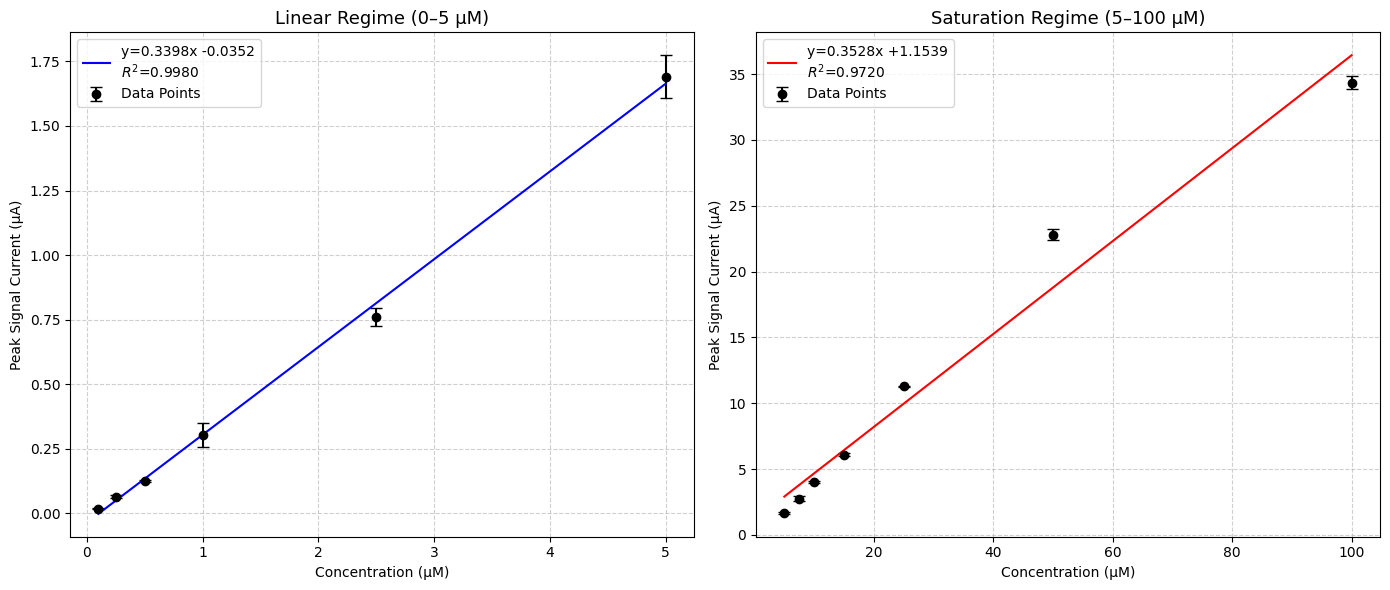

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Load the data
excel_path = 'datasets/Standard calibration in culture media_extended.xlsx'
df_cc = pd.read_excel(excel_path, sheet_name='CC')

# 1. Prepare data
data = df_cc.iloc[4:16, [10, 17, 18]].copy()
data.columns = ['Concentration', 'Signal', 'Stdev']
data = data.apply(pd.to_numeric, errors='coerce').dropna()
data = data.sort_values('Concentration')

# 2. Split data at the 25 uM breakpoint
low_data = data[data['Concentration'] <= 5.0]
high_data = data[data['Concentration'] >= 5.0]

# 3. Calculate fits
slope_low, int_low, r_low, _, _ = linregress(low_data['Concentration'], low_data['Signal'])
slope_high, int_high, r_high, _, _ = linregress(high_data['Concentration'], high_data['Signal'])

# 4. Generate side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left Plot: Linear Regime
ax1.errorbar(low_data['Concentration'], low_data['Signal'], yerr=low_data['Stdev'], 
             fmt='ko', label='Data Points', capsize=4)
ax1.plot(low_data['Concentration'], int_low + slope_low * low_data['Concentration'], 'b-', 
         label=f'y={slope_low:.4f}x {int_low:+.4f}\n$R^2$={r_low**2:.4f}')
ax1.set_title('Linear Regime (0–5 µM)', fontsize=13)
ax1.set_xlabel('Concentration (µM)')
ax1.set_ylabel('Peak Signal Current (µA)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Right Plot: Saturation Regime
ax2.errorbar(high_data['Concentration'], high_data['Signal'], yerr=high_data['Stdev'], 
             fmt='ko', label='Data Points', capsize=4)
ax2.plot(high_data['Concentration'], int_high + slope_high * high_data['Concentration'], 'r-', 
         label=f'y={slope_high:.4f}x {int_high:+.4f}\n$R^2$={r_high**2:.4f}')
ax2.set_title('Saturation Regime (5–100 µM)', fontsize=13)
ax2.set_xlabel('Concentration (µM)')
ax2.set_ylabel('Peak Signal Current (µA)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

---
## Build Mean Base Curves for All 12 Anchors

For each anchor concentration we compute the mean baseline-subtracted signal across all replicates, then apply a Savitzky–Golay smooth to reduce inter-replicate noise before using it as an interpolation template.

In [ ]:
def mean_baseline_subtracted(signals_matrix, I_baseline, concentrations, target_uM):
    """Return mean baseline-subtracted signal across all replicates at target_uM."""
    idxs  = [i for i, c in enumerate(concentrations) if c == target_uM]
    I_subs = [signals_matrix[:, i] - I_baseline for i in idxs]
    return np.mean(I_subs, axis=0)

# Build the anchor dictionary {concentration: mean_baseline_subtracted_signal}
base_curves = {
    c: mean_baseline_subtracted(signals_raw, I_baseline_raw, CONCENTRATIONS, c)
    for c in ANCHOR_CONCENTRATIONS
}

# Report Ip for each anchor (smoothed before Peak detection)
print(f"{'Anchor (µM)':>12}  {'Ip (µA)':>10}  {'Ep (V)':>10}  {'Replicates':>10}")
print("-" * 50)
for c in ANCHOR_CONCENTRATIONS:
    n_reps = sum(1 for x in CONCENTRATIONS if x == c)
    pk = Peak(E_global, savgol_filter(base_curves[c], 5, 3))
    print(f"{c:>12}  {pk.Ip:>10.4f}  {pk.Ep:>10.4f}  {n_reps:>10}")

 Anchor (µM)     Ip (µA)      Ep (V)  Replicates
--------------------------------------------------
         0.1      0.0176     -0.3487           5
        0.25      0.0656     -0.3535           3
         0.5      0.1042     -0.3777           6
         1.0      0.2683     -0.3970           3
         2.5      0.7622     -0.3970           2
         5.0      1.6824     -0.3970           3
         7.5      2.7481     -0.3970           3
        10.0      4.0259     -0.3922           3
        15.0      6.1034     -0.3873           3
        25.0     11.2659     -0.3873           3
        50.0     22.7570     -0.3825           3
       100.0     34.2401     -0.3825           3


---
## Characterising the Ip–Concentration Relationship

### Why Linear Interpolation Fails Above 25 µM

The Ip–concentration relationship is linear only at low concentrations. At higher concentrations, the relationship is no longer linear because the surface saturation effects reduce the marginal current per added molecule. (signal saturation)

The concrete data ilustrates:

| Segment | Δc | Expected ΔIp (linear) | Observed ΔIp ratio |
|---|---|---|---|
| 5 → 10 µM | ×2 | ×2 | ~×2 |
| 50 → 100 µM | ×2 | ×2 | ~×1.5 |

Linear interpolation in the 50–100 µM segment would systematically over-predict Ip, producing physically invalid synthetic records.

### Solution: PCHIP Spline on Empirical Ip Values

I try the Piecewise Cubic Hermite Interpolating Polynomial (PCHIP) to the 12 Ip values. PCHIP preserves monotonicity between data points (no oscillation artefacts) and captures the sub-linear rolloff at high concentrations.

The corrected interpolation weight `α_corr` is derived from the PCHIP Ip–curve rather than from the raw concentration fraction:

$$\alpha_{\text{PCHIP}} = \frac{\hat{I}_p(c_{\text{target}}) - \hat{I}_p(c_{\text{low}})}{\hat{I}_p(c_{\text{high}}) - \hat{I}_p(c_{\text{low}})}$$

(pozitia relativa a valorii tintă in interiorul unui „segment” definit de doua puncte de calibrare cunoscute.)


This maps the concentration target to a current-space interpolation weight, so the blended curve has exactly the Ip the PCHIP model predicts (not what a naive linear α would produce - it would go in the middle if naive, but using PCHIP because of the saturation, la $15 \mu M$ curentul ar putea fi deja la $70\%$ din valoarea maximă a intervalului, nu la $50\%$).

For the 50–100 µM example with a target of 75 µM:

- Linear α = (75 − 50)/(100 − 50) = **0.50** → Ip_blend = 0.50 × Ip₅₀ + 0.50 × Ip₁₀₀  
- PCHIP α ≈ **0.40** (because the curve bends sub-linearly) → lower Ip blend, physically correct

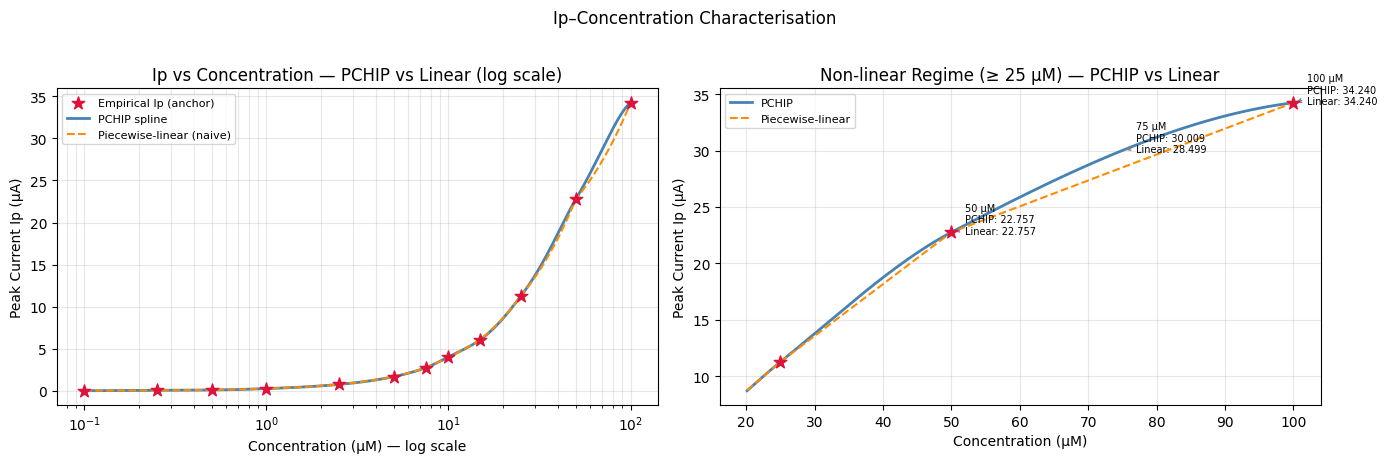


At 75 µM (midpoint of 50–100 µM segment):
  PCHIP Ip  = 30.0094 µA
  Linear Ip = 28.4986 µA
  Over-prediction from linear = -1.5109 µA  (-5.0%)


In [ ]:
# Extract smoothed Ip values at each anchor
anchor_Ip = {}
for c in ANCHOR_CONCENTRATIONS:
    pk = Peak(E_global, savgol_filter(base_curves[c], 5, 3))
    anchor_Ip[c] = pk.Ip

# data for interpolation
c_arr  = np.array(ANCHOR_CONCENTRATIONS)
Ip_arr = np.array([anchor_Ip[c] for c in ANCHOR_CONCENTRATIONS])

# !!!!!!! Fit a PCHIP interpolant: Ip = f(concentration)
pchip_Ip = PchipInterpolator(c_arr, Ip_arr)


# visualisation

# Ip–c relationship
c_fine = np.linspace(c_arr.min(), c_arr.max(), 500) # fine curve for smooth plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: log-scale shows both low and high concentration behaviour
ax = axes[0]
ax.scatter(c_arr, Ip_arr, s=90, zorder=5, color='crimson', marker='*', label='Empirical Ip (anchor)')
ax.plot(c_fine, pchip_Ip(c_fine), color='steelblue', lw=2, label='PCHIP spline')

# Overlay naive linear baseline for comparison
Ip_linear_full = np.interp(c_fine, c_arr, Ip_arr)
ax.plot(c_fine, Ip_linear_full, color='darkorange', lw=1.5, ls='--', label='Piecewise-linear (naive)')

ax.set_xscale('log')
ax.set_xlabel('Concentration (µM) — log scale')
ax.set_ylabel('Peak Current Ip (µA)')
ax.set_title('Ip vs Concentration — PCHIP vs Linear (log scale)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')

# Right: linear scale focused on the 25–100 µM non-linear regime
ax2 = axes[1]
mask = c_fine >= 20
ax2.scatter(c_arr[c_arr >= 20], Ip_arr[c_arr >= 20], s=90, zorder=5, color='crimson', marker='*')
ax2.plot(c_fine[mask], pchip_Ip(c_fine)[mask], color='steelblue', lw=2, label='PCHIP')
ax2.plot(c_fine[mask], Ip_linear_full[mask], color='darkorange', lw=1.5, ls='--', label='Piecewise-linear')

# Annotate the 50 - 100 µM gap
for c_pt in [50, 75, 100]:
    Ip_pchip  = float(pchip_Ip(c_pt))
    Ip_lin    = float(np.interp(c_pt, c_arr, Ip_arr))
    ax2.annotate(f'{c_pt} µM\nPCHIP: {Ip_pchip:.3f}\nLinear: {Ip_lin:.3f}',
                 xy=(c_pt, Ip_pchip),
                 xytext=(c_pt + 2, Ip_pchip - 0.15),
                 fontsize=7, arrowprops=dict(arrowstyle='->', color='gray'))

ax2.set_xlabel('Concentration (µM)')
ax2.set_ylabel('Peak Current Ip (µA)')
ax2.set_title('Non-linear Regime (≥ 25 µM) — PCHIP vs Linear')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.suptitle('Ip–Concentration Characterisation', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# Quantify the divergence in the 50-100 µM segment
Ip_75_pchip  = float(pchip_Ip(75))
Ip_75_linear = float(np.interp(75, c_arr, Ip_arr))
print(f"\nAt 75 µM (midpoint of 50–100 µM segment):")
print(f"  PCHIP Ip  = {Ip_75_pchip:.4f} µA")
print(f"  Linear Ip = {Ip_75_linear:.4f} µA")
print(f"  Over-prediction from linear = {(Ip_75_linear - Ip_75_pchip):.4f} µA  ({(Ip_75_linear/Ip_75_pchip - 1)*100:.1f}%)")

Zona $10^{-1}$ – $10^{1}$ ($0.1$ – $10 \mu M$ senzoruleste într-un regim liniar ideal. Creșterea curentului este direct proporțională cu concentrația.
Zona $10^{1}$ – $10^{2}$ ($10$ – $100 \mu M$): Curba începe să se „îndoaie” vizibil în sus pe scara logaritmică. Această pantă abruptă arată că semnalul crește puternic, distanța pe axa Y începe să se comprime spre final.

---
Augmentation Functions

`get_base_pair` — Extended to All 12 Anchors

The lookup table now covers the full concentration axis. For any target `c`, we return the two adjacent anchor concentrations and their base curves.

In [ ]:
def get_base_pair(c_target: float):
    """
    Return (c_low, I_low, c_high, I_high) bracketing c_target across all 12 anchors.

    For concentrations at or below the minimum anchor (0.1 µM) or above the
    maximum (100 µM), the nearest boundary pair is used for extrapolation
    (conservative; avoids out-of-range spline behaviour).
    """
    # Guard: clamp to the observable range
    c_target = float(np.clip(c_target, ANCHOR_CONCENTRATIONS[0], ANCHOR_CONCENTRATIONS[-1]))

    for i in range(len(ANCHOR_CONCENTRATIONS) - 1):
        c_lo = ANCHOR_CONCENTRATIONS[i] # inferior limit
        c_hi = ANCHOR_CONCENTRATIONS[i + 1] # superior limit
        if c_lo <= c_target <= c_hi:
            return c_lo, base_curves[c_lo], c_hi, base_curves[c_hi]

    # Should never reach here after clamping, but fall back to last segment
    return ANCHOR_CONCENTRATIONS[-2], base_curves[ANCHOR_CONCENTRATIONS[-2]], ANCHOR_CONCENTRATIONS[-1], base_curves[ANCHOR_CONCENTRATIONS[-1]]


# Quick sanity check
for c_test in [0.15, 0.75, 3.0, 12.0, 30.0, 75.0]:
    c_lo, _, c_hi, _ = get_base_pair(c_test)
    print(f"  target = {c_test:6.2f} µM  →  segment [{c_lo}, {c_hi}] µM")

  target =   0.15 µM  →  segment [0.1, 0.25] µM
  target =   0.75 µM  →  segment [0.5, 1.0] µM
  target =   3.00 µM  →  segment [2.5, 5.0] µM
  target =  12.00 µM  →  segment [10.0, 15.0] µM
  target =  30.00 µM  →  segment [25.0, 50.0] µM
  target =  75.00 µM  →  segment [50.0, 100.0] µM


### PCHIP-corrected Interpolation

Standard linear blend with the PCHIP-corrected alpha weight.

**For segments ≤ 25 µM**: the PCHIP spline closely follows a linear trend (Faradaic regime), so the corrected alpha barely differs from `(c_target − c_low) / (c_high − c_low)`. The function is safe to use uniformly.

**For segments > 25 µM**: the corrected alpha is noticeably smaller than the linear alpha, pulling the blended curve's Ip down to the physically correct value.

In [ ]:
def interpolate_base_curve(c_target: float, c_low: float, I_low: np.ndarray,
                           c_high: float, I_high: np.ndarray) -> np.ndarray:
    """
    Blend two base curves weighted by the PCHIP-corrected alpha.
    Alpha is computed in current-space using the PCHIP Ip spline:
        alpha_PCHIP = (Ip_hat(c_target) - Ip_hat(c_low)) / (Ip_hat(c_high) - Ip_hat(c_low))
    This ensures the blended curve has the physically correct peak current for
    all segments, especially the non-linear high-concentration regime.
    """
    if c_high == c_low:
        return I_low.copy()

    Ip_low    = float(pchip_Ip(c_low))
    Ip_high   = float(pchip_Ip(c_high))
    Ip_target = float(pchip_Ip(c_target))

    denom = Ip_high - Ip_low
    if abs(denom) < 1e-9:
        # if identical Ip: fall back to concentration linear
        alpha = (c_target - c_low) / (c_high - c_low)
    else:
        alpha = (Ip_target - Ip_low) / denom

    alpha = float(np.clip(alpha, 0.0, 1.0))  # numerical safety
    return (1.0 - alpha) * I_low + alpha * I_high


# Demonstrate alpha correction for the 50-100 µM segment
print("Alpha comparison — 50 → 100 µM segment")
print(f"{'c_target':>10}  {'alpha_linear':>13}  {'alpha_PCHIP':>12}  {'Ip_PCHIP':>10}")
print("-" * 52)
for c_t in [55, 60, 65, 70, 75, 80, 85, 90, 95]:
    alpha_lin   = (c_t - 50) / (100 - 50)
    Ip_lo       = float(pchip_Ip(50))
    Ip_hi       = float(pchip_Ip(100))
    # curentul pe care senzorul ar trebui sa
    # il produca daca fenomenul de saturatie a piocianinei 
    # urmeaza traiectoria curba determinata de restul punctelor masurate
    Ip_t        = float(pchip_Ip(c_t)) 
    alpha_pchip = (Ip_t - Ip_lo) / (Ip_hi - Ip_lo)
    print(f"{c_t:>10}  {alpha_lin:>13.4f}  {alpha_pchip:>12.4f}  {Ip_t:>10.4f}")

Alpha comparison — 50 → 100 µM segment
  c_target   alpha_linear   alpha_PCHIP    Ip_PCHIP
----------------------------------------------------
        55         0.1000        0.1372     24.3324
        60         0.2000        0.2706     25.8648
        65         0.3000        0.3987     27.3348
        70         0.4000        0.5195     28.7228
        75         0.5000        0.6316     30.0094
        80         0.6000        0.7331     31.1752
        85         0.7000        0.8224     32.2006
        90         0.8000        0.8978     33.0662
        95         0.9000        0.9575     33.7525


### Noise, Baseline Variation, and Potential Drift

Identical implementations to the parent notebook, unchanged.

In [7]:
NOISE_SIGMA = 0.001  # µA — strictly limited to preserve chemical validity

def add_gaussian_noise(I: np.ndarray, sigma: float = NOISE_SIGMA) -> np.ndarray:
    """Additive Gaussian white noise simulating instrument current fluctuations."""
    return I + np.random.normal(0.0, sigma, size=I.shape)


def add_baseline_variation(I: np.ndarray, E: np.ndarray, max_amp: float = 0.05) -> np.ndarray:
    """
    Smooth polynomial distortion: amp * (E_norm² − E_norm⁴).
    Anchored near zero at both potential extremes to avoid DC shift.
    E is normalised to [-0.5, +0.5] for symmetric shaping.
    """
    amp    = np.random.uniform(-max_amp, max_amp)
    E_norm = (E - E.mean()) / (E.max() - E.min())
    distortion = amp * (E_norm ** 2 - E_norm ** 4)
    return I + distortion


def apply_potential_drift(I: np.ndarray, E: np.ndarray,
                          sigma_low: float = 0.01, sigma_high: float = 0.03) -> np.ndarray:
    """
    Horizontal iR-drop shift: delta_E ~ N(0, sigma_drift), sigma_drift ~ U(sigma_low, sigma_high).
    The shifted signal is re-sampled back onto the original E grid via linear interpolation.
    """
    sigma_drift = np.random.uniform(sigma_low, sigma_high)
    delta_E     = np.random.normal(0.0, sigma_drift)
    E_shifted   = E + delta_E
    return np.interp(E, E_shifted, I, left=I[0], right=I[-1])


def generate_synthetic_signal(c_target: float) -> np.ndarray:
    """Full augmentation pipeline for one synthetic sample at concentration c_target."""
    c_low, I_low, c_high, I_high = get_base_pair(c_target)
    I = interpolate_base_curve(c_target, c_low, I_low, c_high, I_high)
    I = add_gaussian_noise(I)
    I = add_baseline_variation(I, E_global)
    I = apply_potential_drift(I, E_global)
    return I

print("Augmentation helpers ready.")

Augmentation helpers ready.


---
## Stratified Sampling Strategy

* WIP *
